In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)  # makes random numbers reproducible
print("Ready. Building neural network from scratch.")

Ready. Building neural network from scratch.


Real Delhi Data

In [3]:
# dataset
df = pd.read_csv('delhi_newdelhi_2020_2026_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Same features and target as our AQI project
features = ['pm10', 'no2', 'so2', 'o3', 'co',
            'month', 'day_of_year', 'is_winter']
target = 'pm25'

# missing values
for col in features:
    df[col] = df[col].fillna(df[col].median())

X_raw = df[features].values    # shape (1008, 8)
y_raw = df[target].values      # shape (1008,)

print(f"X shape : {X_raw.shape}")
print(f"y shape : {y_raw.shape}")
print(f"\nFirst row of X: {X_raw[0]}")
print(f"First value of y: {y_raw[0]}")

X shape : (1008, 8)
y shape : (1008,)

First row of X: [5.71708333e+02 5.10541667e+01 1.96900000e+01 8.47180556e+01
 1.24888889e+03 1.00000000e+00 1.00000000e+00 1.00000000e+00]
First value of y: 434.2535211267606


Normalise the Data

In [4]:
split = int(0.8 * len(X_raw))     
X_train_raw = X_raw[:split]
X_test_raw  = X_raw[split:]
y_train      = y_raw[:split].reshape(-1, 1)  
y_test       = y_raw[split:].reshape(-1, 1)

X_mean = X_train_raw.mean(axis=0)   
X_std  = X_train_raw.std(axis=0)    

X_train = (X_train_raw - X_mean) / (X_std + 1e-8)
X_test  = (X_test_raw  - X_mean) / (X_std + 1e-8)

y_mean  = y_train.mean()
y_std   = y_train.std()
y_train_norm = (y_train - y_mean) / y_std
y_test_norm  = (y_test  - y_mean) / y_std

print(f"X_train shape : {X_train.shape}")   # (806, 8)
print(f"X_test shape  : {X_test.shape}")    # (202, 8)
print(f"\nBefore normalisation — PM10 mean : {X_train_raw[:,0].mean():.1f}")
print(f"After  normalisation — PM10 mean : {X_train[:,0].mean():.4f}")

X_train shape : (806, 8)
X_test shape  : (202, 8)

Before normalisation — PM10 mean : 206.9
After  normalisation — PM10 mean : -0.0000


Activation Functions

In [5]:
def relu(x):
    # if x < 0 → return 0
    # if x >= 0 → return x unchanged
    return np.maximum(0, x)

def relu_derivative(x):
    # Derivative of ReLU — needed for backpropagation
    # if x > 0 → slope is 1 (output changes at same rate as input)
    # if x <= 0 → slope is 0 (flat line, no change)
    return (x > 0).astype(float)

def linear(x):
    # No transformation — output = input
    # Used in final layer for regression
    return x

def linear_derivative(x):
    # Derivative of a straight line = 1 always
    return np.ones_like(x)

test_values = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
print("Test values      :", test_values)
print("ReLU output      :", relu(test_values))
print("ReLU derivative  :", relu_derivative(test_values))

Test values      : [-3. -1.  0.  1.  3.]
ReLU output      : [0. 0. 0. 1. 3.]
ReLU derivative  : [0. 0. 0. 1. 1.]


Neural Network Class

In [6]:
class NeuralNetwork:
    
    #A 3-layer neural network built NumPy.
    
    #Architecture:
    #Input (8 features) → Hidden Layer 1 (64 neurons) →  Hidden Layer 2 (32 neurons) → Output (1 value = PM2.5)

    
    def __init__(self, layer_sizes, learning_rate=0.001):
    
        #layer_sizes = [8, 64, 32, 1] Means: 8 inputs → 64 neurons → 32 neurons → 1 output

        self.lr = learning_rate
        self.weights = []
        self.biases  = []
        
        # Initialise weights and biases for each layer
        for i in range(len(layer_sizes) - 1):
            input_size  = layer_sizes[i]
            output_size = layer_sizes[i + 1]
            
            # He initialisation — designed for ReLU networks
            # Dividing by sqrt(input_size) keeps values in a good range
            # Random weights that are too large → exploding gradients
            # Random weights that are too small → vanishing gradients
            W = np.random.randn(input_size, output_size) * np.sqrt(2.0 / input_size)
            b = np.zeros((1, output_size))   # biases start at 0
            
            self.weights.append(W)
            self.biases.append(b)
            print(f"Layer {i+1}: W shape = {W.shape}, b shape = {b.shape}")
    
    # ── FORWARD PASS ─────────────────────────────────────────────
    def forward(self, X):
        
        #X travels through every layer:
        #raw_output = X @ W + b   (dot product + bias)
        #activated  = relu(raw_output)   (except last layer = linear)

        self.activations = [X]     # store all activations for backprop
        self.raw_outputs = []      # store raw outputs (before activation)
        
        current = X
        
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            # Dot product + bias
            # @ is matrix multiplication in NumPy (same as np.dot)
            raw = current @ W + b
            self.raw_outputs.append(raw)
            
            # Apply activation
            # Last layer → linear (regression output)
            # All other layers → ReLU
            if i == len(self.weights) - 1:
                activated = linear(raw)
            else:
                activated = relu(raw)
            
            self.activations.append(activated)
            current = activated
        
        return current   # final prediction
    
    # ── LOSS FUNCTION ────────────────────────────────────────────
    def compute_loss(self, y_pred, y_true):
        
        #Mean Squared Error — average of (predicted - actual)² - This is what we minimise during training
        
        return np.mean((y_pred - y_true) ** 2)
    
    # ── BACKWARD PASS (BACKPROPAGATION) ──────────────────────────
    def backward(self, y_true):
        
        #We calculate how much each weight contributed to the error. Then we adjust each weight to reduce that contribution.
        #We move BACKWARDS through the network — output layer first, then hidden layer 2, then hidden layer 1.
        
        m = y_true.shape[0]   # number of training examples
        
        # Start from the output — how wrong were we?
        # Derivative of MSE loss with respect to prediction
        # d(Loss)/d(prediction) = 2/m × (prediction - actual)
        delta = 2/m * (self.activations[-1] - y_true)
        
        # Move backwards through each layer
        for i in reversed(range(len(self.weights))):
            
            # Gradient of activation function
            if i == len(self.weights) - 1:
                grad_activation = linear_derivative(self.raw_outputs[i])
            else:
                grad_activation = relu_derivative(self.raw_outputs[i])
            
            # Apply chain rule — multiply gradients together
            delta = delta * grad_activation
            
            # How much did each weight contribute to the error?
            # activations[i] = input to this layer
            dW = self.activations[i].T @ delta / m
            db = np.mean(delta, axis=0, keepdims=True)
            
            # Pass error signal to previous layer
            delta = delta @ self.weights[i].T
            
            # ── UPDATE WEIGHTS ───────────────────────────────────
            # This is gradient descent:
            # new_weight = old_weight - learning_rate × gradient
            # We subtract because we want to go DOWNHILL (reduce loss)
            self.weights[i] -= self.lr * dW
            self.biases[i]  -= self.lr * db
    
    # ── TRAINING LOOP ────────────────────────────────────────────
    def train(self, X, y, epochs=500, verbose=True):

        #Repeat forward + backward pass for every epoch
        #Each pass: model sees all data, makes predictions, calculates error, adjusts all weights
        
        self.loss_history = []
        
        for epoch in range(epochs):
            # Forward pass — make predictions
            y_pred = self.forward(X)
            
            # Calculate loss
            loss = self.compute_loss(y_pred, y)
            self.loss_history.append(loss)
            
            # Backward pass — update weights
            self.backward(y)
            
            # Print progress every 50 epochs
            if verbose and epoch % 50 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")
        
        print(f"\n Training complete! Final loss: {loss:.6f}")
    
    # ── PREDICTION ───────────────────────────────────────────────
    def predict(self, X):
        return self.forward(X)


print("NeuralNetwork class defined")
print("\nArchitecture we will build:")
print("Input(8) → Hidden1(64, ReLU) → Hidden2(32, ReLU) → Output(1, Linear)")

NeuralNetwork class defined

Architecture we will build:
Input(8) → Hidden1(64, ReLU) → Hidden2(32, ReLU) → Output(1, Linear)


Training

In [7]:
# Create the network
# [8, 64, 32, 1] means:
# 8 input features → 64 neurons → 32 neurons → 1 output
nn = NeuralNetwork(
    layer_sizes=[8, 64, 32, 1],
    learning_rate=0.001
)

print("\nStarting training...")
print("="*45)

# Train on normalised data
nn.train(X_train, y_train_norm, epochs=500)

Layer 1: W shape = (8, 64), b shape = (1, 64)
Layer 2: W shape = (64, 32), b shape = (1, 32)
Layer 3: W shape = (32, 1), b shape = (1, 1)

Starting training...
Epoch    0 | Loss: 1.935484
Epoch   50 | Loss: 1.930828
Epoch  100 | Loss: 1.926196
Epoch  150 | Loss: 1.921589
Epoch  200 | Loss: 1.917004
Epoch  250 | Loss: 1.912444
Epoch  300 | Loss: 1.907913
Epoch  350 | Loss: 1.903403
Epoch  400 | Loss: 1.898915
Epoch  450 | Loss: 1.894450

 Training complete! Final loss: 1.890096


Plot the Learning

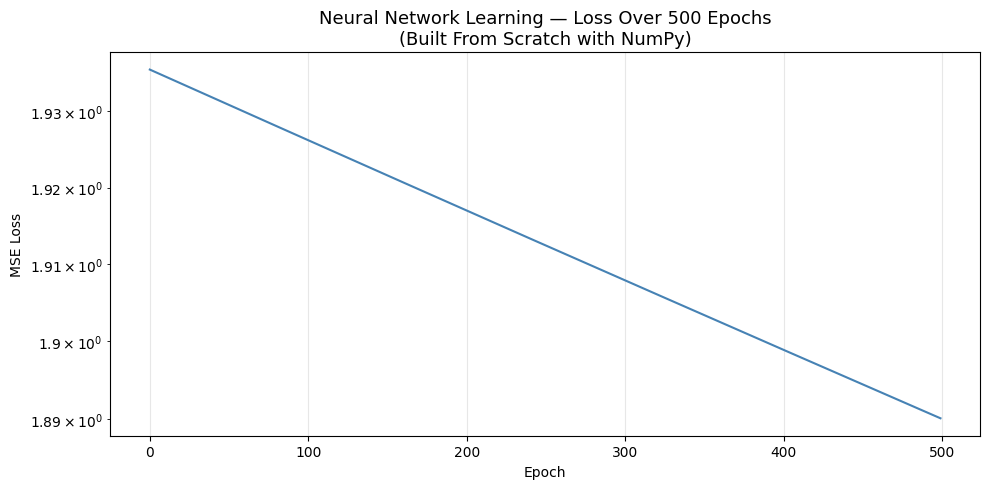

Starting loss : 1.935484
Final loss    : 1.890096
Improvement   : 2.3%


In [8]:
plt.figure(figsize=(10, 5))
plt.plot(nn.loss_history, color='steelblue', linewidth=1.5)
plt.title('Neural Network Learning — Loss Over 500 Epochs\n(Built From Scratch with NumPy)', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')    # log scale so you can see the curve clearly
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting loss : {nn.loss_history[0]:.6f}")
print(f"Final loss    : {nn.loss_history[-1]:.6f}")
print(f"Improvement   : {((nn.loss_history[0] - nn.loss_history[-1])/nn.loss_history[0]*100):.1f}%")

Evaluate Against Random Forest

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

# Get predictions on test set
y_pred_norm = nn.predict(X_test)

# Denormalise — convert back to real PM2.5 values
y_pred_real = (y_pred_norm * y_std) + y_mean
y_test_real = (y_test_norm * y_std) + y_mean

# Calculate metrics
mae = mean_absolute_error(y_test_real, y_pred_real)
r2  = r2_score(y_test_real, y_pred_real)

print("=" * 55)
print("  COMPARISON")
print("=" * 55)
print(f"  {'Model':<30} {'MAE':>8}  {'R²':>8}")
print("-" * 55)
print(f"  {'Random Forest (Week 0)':<30} {'12.40':>8}  {'0.9501':>8}")
print(f"  {'Neural Net From Scratch':<30} {mae:>8.2f}  {r2:>8.4f}")
print("=" * 55)

  COMPARISON
  Model                               MAE        R²
-------------------------------------------------------
  Random Forest (Week 0)            12.40    0.9501
  Neural Net From Scratch          169.56   -2.9385


EXPERIMENT 1 — Increase Learning Rate

Layer 1: W shape = (8, 64), b shape = (1, 64)
Layer 2: W shape = (64, 32), b shape = (1, 32)
Layer 3: W shape = (32, 1), b shape = (1, 1)
Epoch    0 | Loss: 3.173532
Epoch   50 | Loss: 3.107724
Epoch  100 | Loss: 3.044330
Epoch  150 | Loss: 2.983273
Epoch  200 | Loss: 2.924252
Epoch  250 | Loss: 2.867102
Epoch  300 | Loss: 2.811797
Epoch  350 | Loss: 2.758397
Epoch  400 | Loss: 2.706622
Epoch  450 | Loss: 2.656483

 Training complete! Final loss: 2.608780


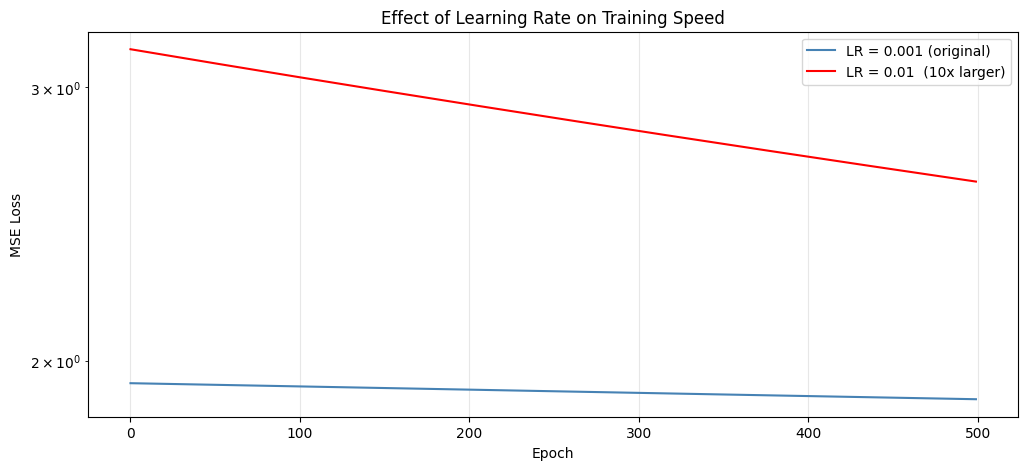

LR 0.001 final loss : 1.890096
LR 0.01  final loss : 2.608780


In [10]:
# Experiment 1 — Learning rate 10x larger
nn_exp1 = NeuralNetwork(
    layer_sizes=[8, 64, 32, 1],
    learning_rate=0.01    # was 0.001, now 0.01
)

nn_exp1.train(X_train, y_train_norm, epochs=500)

# Plot comparison
plt.figure(figsize=(12, 5))
plt.plot(nn.loss_history,     label='LR = 0.001 (original)', color='steelblue')
plt.plot(nn_exp1.loss_history, label='LR = 0.01  (10x larger)', color='red')
plt.title('Effect of Learning Rate on Training Speed')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"LR 0.001 final loss : {nn.loss_history[-1]:.6f}")
print(f"LR 0.01  final loss : {nn_exp1.loss_history[-1]:.6f}")

EXPERIMENT 2 — Learning Rate Too Large 

Layer 1: W shape = (8, 64), b shape = (1, 64)
Layer 2: W shape = (64, 32), b shape = (1, 32)
Layer 3: W shape = (32, 1), b shape = (1, 1)
Epoch    0 | Loss: 5.137497
Epoch   50 | Loss: 0.478995

 Training complete! Final loss: 0.336446


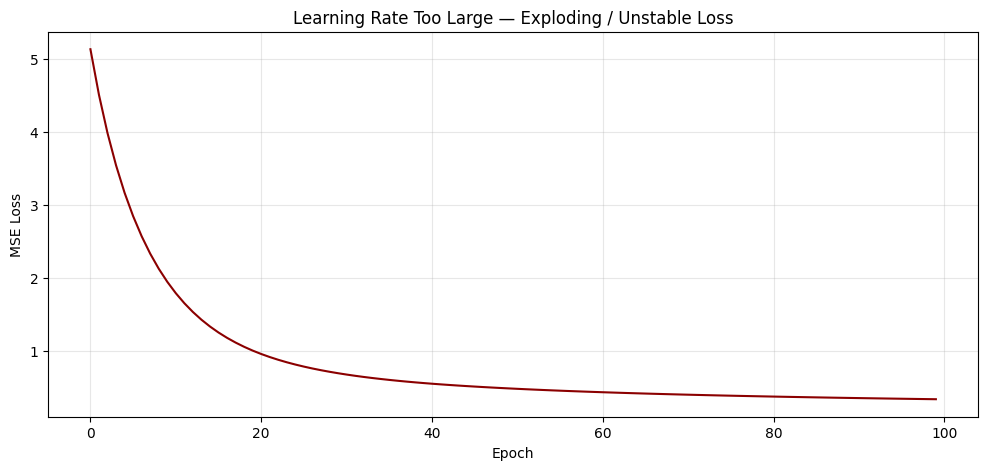

Final loss: 0.336446


In [11]:
# Experiment 2 — Learning rate WAY too large
# This will show you exploding gradients
nn_exp2 = NeuralNetwork(
    layer_sizes=[8, 64, 32, 1],
    learning_rate=1.0     # dangerously large
)

nn_exp2.train(X_train, y_train_norm, epochs=100)

plt.figure(figsize=(12, 5))
plt.plot(nn_exp2.loss_history, color='darkred', linewidth=1.5)
plt.title('Learning Rate Too Large — Exploding / Unstable Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.show()

# You'll likely see loss jumping wildly or going to NaN
# This is the model overshooting the valley and bouncing around
print(f"Final loss: {nn_exp2.loss_history[-1]:.6f}")

EXPERIMENT 3 — The Right Learning Rate + More Epochs

Layer 1: W shape = (8, 64), b shape = (1, 64)
Layer 2: W shape = (64, 32), b shape = (1, 32)
Layer 3: W shape = (32, 1), b shape = (1, 1)
Epoch    0 | Loss: 3.087109
Epoch   50 | Loss: 2.933119
Epoch  100 | Loss: 2.792004
Epoch  150 | Loss: 2.662566
Epoch  200 | Loss: 2.543581
Epoch  250 | Loss: 2.434095
Epoch  300 | Loss: 2.333395
Epoch  350 | Loss: 2.240149
Epoch  400 | Loss: 2.153728
Epoch  450 | Loss: 2.073335
Epoch  500 | Loss: 1.998707
Epoch  550 | Loss: 1.929394
Epoch  600 | Loss: 1.864854
Epoch  650 | Loss: 1.804881
Epoch  700 | Loss: 1.749095
Epoch  750 | Loss: 1.697124
Epoch  800 | Loss: 1.648589
Epoch  850 | Loss: 1.603012
Epoch  900 | Loss: 1.560279
Epoch  950 | Loss: 1.520231
Epoch 1000 | Loss: 1.482683
Epoch 1050 | Loss: 1.447594
Epoch 1100 | Loss: 1.414987
Epoch 1150 | Loss: 1.384513
Epoch 1200 | Loss: 1.355894
Epoch 1250 | Loss: 1.328860
Epoch 1300 | Loss: 1.303431
Epoch 1350 | Loss: 1.279259
Epoch 1400 | Loss: 1.256294
Epoch 1450 | Loss: 1.234542
Epoch 1500 | Loss: 1.2

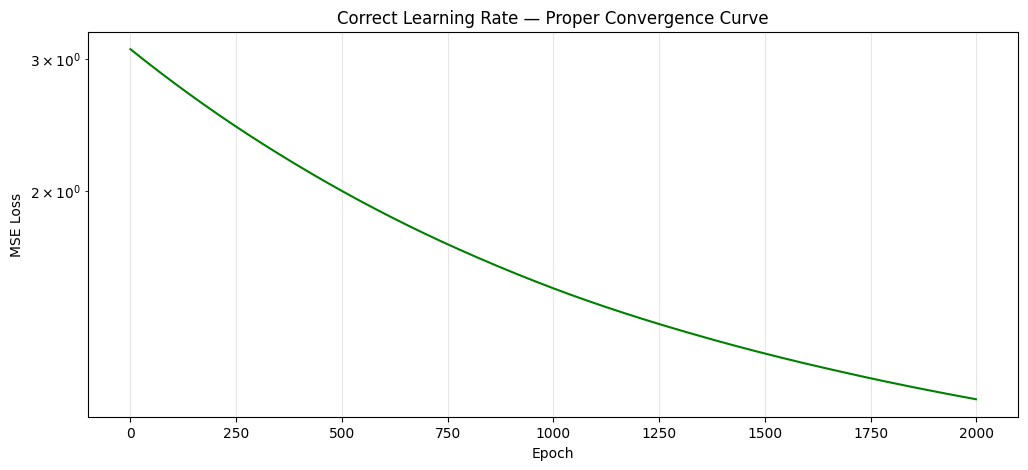

Epoch 0    loss : 3.087109
Epoch 500  loss : 2.000145
Epoch 2000 loss : 1.055245


In [12]:
# Experiment 3 — Sweet spot learning rate + enough epochs
nn_best = NeuralNetwork(
    layer_sizes=[8, 64, 32, 1],
    learning_rate=0.01
)

# More epochs now that learning rate is right
nn_best.train(X_train, y_train_norm, epochs=2000)

plt.figure(figsize=(12, 5))
plt.plot(nn_best.loss_history, color='green', linewidth=1.5)
plt.title('Correct Learning Rate — Proper Convergence Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Epoch 0    loss : {nn_best.loss_history[0]:.6f}")
print(f"Epoch 500  loss : {nn_best.loss_history[499]:.6f}")
print(f"Epoch 2000 loss : {nn_best.loss_history[-1]:.6f}")

Evaluate the Best Model

In [13]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_norm = nn_best.predict(X_test)
y_pred_real = (y_pred_norm * y_std) + y_mean
y_test_real = (y_test_norm * y_std) + y_mean

mae = mean_absolute_error(y_test_real, y_pred_real)
r2  = r2_score(y_test_real, y_pred_real)

print("=" * 55)
print("  RESULTS AFTER FIXING LEARNING RATE")
print("=" * 55)
print(f"  {'Model':<30} {'MAE':>8}  {'R²':>8}")
print("-" * 55)
print(f"  {'Random Forest':<30} {'12.40':>8}  {'0.9501':>8}")
print(f"  {'NN scratch LR=0.001':<30} {'?':>8}  {'?':>8}  ← broken")
print(f"  {'NN scratch LR=0.01':<30} {mae:>8.2f}  {r2:>8.4f}  ← fixed")
print("=" * 55)

  RESULTS AFTER FIXING LEARNING RATE
  Model                               MAE        R²
-------------------------------------------------------
  Random Forest                     12.40    0.9501
  NN scratch LR=0.001                   ?         ?  ← broken
  NN scratch LR=0.01                58.64    0.3742  ← fixed


Add Adam Optimiser to NeuralNetwork Class

In [14]:
class NeuralNetworkAdam:
    """
    Same network as before — but with Adam optimiser.
    Adam = Adaptive Moment Estimation
    Keeps track of:
      m = first moment  (average of recent gradients)
      v = second moment (average of recent gradient squares)
    Uses both to compute smarter, adaptive step sizes.
    """

    def __init__(self, layer_sizes, learning_rate=0.001):
        self.lr     = learning_rate
        self.weights = []
        self.biases  = []

        # Adam specific — moment estimates for each layer
        self.m_w = []   # first moment for weights
        self.v_w = []   # second moment for weights
        self.m_b = []   # first moment for biases
        self.v_b = []   # second moment for biases
        self.t   = 0    # timestep counter

        for i in range(len(layer_sizes) - 1):
            W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2.0 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i+1]))

            self.weights.append(W)
            self.biases.append(b)

            # Initialise all moment estimates to zero
            self.m_w.append(np.zeros_like(W))
            self.v_w.append(np.zeros_like(W))
            self.m_b.append(np.zeros_like(b))
            self.v_b.append(np.zeros_like(b))

    def forward(self, X):
        self.activations = [X]
        self.raw_outputs = []
        current = X

        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            raw = current @ W + b
            self.raw_outputs.append(raw)
            activated = linear(raw) if i == len(self.weights)-1 else relu(raw)
            self.activations.append(activated)
            current = activated

        return current

    def compute_loss(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)

    def backward_adam(self, y_true):
        """
        Same backprop as before — but weight update uses Adam instead
        of simple subtraction.

        Adam update rule:
          m = beta1 × m + (1-beta1) × gradient     ← smooth gradient
          v = beta2 × v + (1-beta2) × gradient²    ← smooth gradient²
          m_hat = m / (1 - beta1^t)                 ← bias correction
          v_hat = v / (1 - beta2^t)                 ← bias correction
          weight = weight - lr × m_hat / (√v_hat + ε)
        """
        # Adam hyperparameters — these are standard, never change them
        beta1 = 0.9      # how much to remember past gradients
        beta2 = 0.999    # how much to remember past gradient squares
        eps   = 1e-8     # prevents division by zero

        self.t += 1      # increment timestep
        m = y_true.shape[0]

        delta = 2/m * (self.activations[-1] - y_true)

        for i in reversed(range(len(self.weights))):
            grad_act = linear_derivative(self.raw_outputs[i]) \
                       if i == len(self.weights)-1 \
                       else relu_derivative(self.raw_outputs[i])

            delta = delta * grad_act
            dW = self.activations[i].T @ delta / m
            db = np.mean(delta, axis=0, keepdims=True)
            delta = delta @ self.weights[i].T

            # ── ADAM UPDATE (replaces simple subtraction) ────────
            # Update first moment — running average of gradients
            self.m_w[i] = beta1 * self.m_w[i] + (1 - beta1) * dW
            self.m_b[i] = beta1 * self.m_b[i] + (1 - beta1) * db

            # Update second moment — running average of gradient²
            self.v_w[i] = beta2 * self.v_w[i] + (1 - beta2) * (dW ** 2)
            self.v_b[i] = beta2 * self.v_b[i] + (1 - beta2) * (db ** 2)

            # Bias correction — compensates for zero initialisation
            # Without this, early steps are too small
            m_w_hat = self.m_w[i] / (1 - beta1 ** self.t)
            m_b_hat = self.m_b[i] / (1 - beta1 ** self.t)
            v_w_hat = self.v_w[i] / (1 - beta2 ** self.t)
            v_b_hat = self.v_b[i] / (1 - beta2 ** self.t)

            # Final weight update — adaptive step per weight
            self.weights[i] -= self.lr * m_w_hat / (np.sqrt(v_w_hat) + eps)
            self.biases[i]  -= self.lr * m_b_hat / (np.sqrt(v_b_hat) + eps)

    def train(self, X, y, epochs=1000, verbose=True):
        self.loss_history = []

        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss   = self.compute_loss(y_pred, y)
            self.loss_history.append(loss)
            self.backward_adam(y)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")

        print(f"\nTraining complete! Final loss: {loss:.6f}")

    def predict(self, X):
        return self.forward(X)


print(" NeuralNetworkAdam class defined")

 NeuralNetworkAdam class defined


Train With Adam and Compare

In [15]:
nn_adam = NeuralNetworkAdam(
    layer_sizes=[8, 64, 32, 1],
    learning_rate=0.001    # same LR as original broken attempt
)

print("Training with Adam optimiser...")
print("="*45)
nn_adam.train(X_train, y_train_norm, epochs=1000)

Training with Adam optimiser...
Epoch    0 | Loss: 1.732320
Epoch  100 | Loss: 0.076958
Epoch  200 | Loss: 0.052908
Epoch  300 | Loss: 0.042106
Epoch  400 | Loss: 0.034507
Epoch  500 | Loss: 0.028062
Epoch  600 | Loss: 0.022736
Epoch  700 | Loss: 0.018696
Epoch  800 | Loss: 0.015323
Epoch  900 | Loss: 0.012799

Training complete! Final loss: 0.011020


Plot Vanilla vs Adam

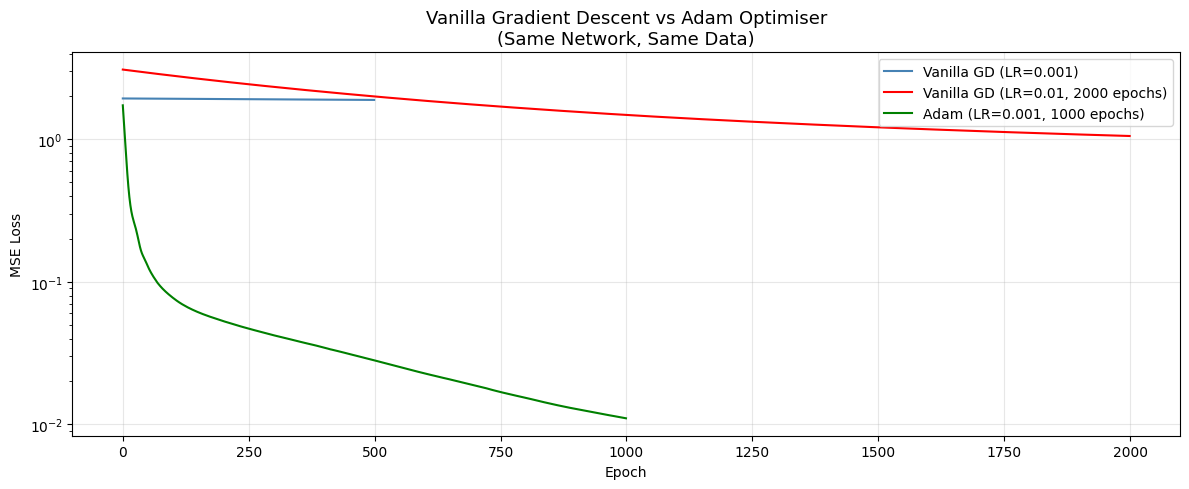

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(nn.loss_history,
         label='Vanilla GD (LR=0.001)',
         color='steelblue', linewidth=1.5)

plt.plot(nn_best.loss_history,
         label='Vanilla GD (LR=0.01, 2000 epochs)',
         color='red', linewidth=1.5)

plt.plot(nn_adam.loss_history,
         label='Adam (LR=0.001, 1000 epochs)',
         color='green', linewidth=1.5)

plt.title('Vanilla Gradient Descent vs Adam Optimiser\n(Same Network, Same Data)',
          fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

# Evaluate Adam model
y_pred_adam_norm = nn_adam.predict(X_test)
y_pred_adam_real = (y_pred_adam_norm * y_std) + y_mean
y_test_real      = (y_test_norm * y_std) + y_mean

mae_adam = mean_absolute_error(y_test_real, y_pred_adam_real)
r2_adam  = r2_score(y_test_real, y_pred_adam_real)

# Full comparison
print("=" * 58)
print("  FULL COMPARISON — All Models")
print("=" * 58)
print(f"  {'Model':<35} {'MAE':>8}  {'R²':>8}")
print("-" * 58)
print(f"  {'Random Forest':<35} {'12.40':>8}  {'0.9501':>8}")
print(f"  {'NN scratch (vanilla GD)':<35} {'58.64':>8}  {'0.3742':>8}")
print(f"  {'NN scratch (Adam)':<35} {mae_adam:>8.2f}  {r2_adam:>8.4f}")
print("=" * 58)

improvement = r2_adam - 0.3742
print(f"\n  Adam vs Vanilla GD : +{improvement:.4f} R²")
print(f"  Gap vs Random Forest: {0.9501 - r2_adam:.4f} R²")

  FULL COMPARISON — All Models
  Model                                    MAE        R²
----------------------------------------------------------
  Random Forest                          12.40    0.9501
  NN scratch (vanilla GD)                58.64    0.3742
  NN scratch (Adam)                      56.53    0.3703

  Adam vs Vanilla GD : +-0.0039 R²
  Gap vs Random Forest: 0.5798 R²


Dropout + Early Stopping Built From Scratch

In [19]:
class NeuralNetworkFinal:

    def __init__(self, layer_sizes, learning_rate=0.001, dropout_rate=0.2):
        self.lr           = learning_rate
        self.dropout_rate = dropout_rate  
        # dropout_rate=0.2 means randomly switch off 20% of neurons
        # during each training step
        # Forces network to not rely on any single neuron
        # Makes it learn more robust, general patterns

        self.weights = []
        self.biases  = []
        self.m_w = []; self.v_w = []
        self.m_b = []; self.v_b = []
        self.t   = 0

        for i in range(len(layer_sizes) - 1):
            W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) \
                * np.sqrt(2.0 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(W)
            self.biases.append(b)
            self.m_w.append(np.zeros_like(W))
            self.v_w.append(np.zeros_like(W))
            self.m_b.append(np.zeros_like(b))
            self.v_b.append(np.zeros_like(b))

    def forward(self, X, training=True):
        """
        training=True  → apply dropout (during training)
        training=False → no dropout   (during evaluation/prediction)

        Why turn off dropout for prediction?
        During training dropout randomly disables neurons — this adds
        noise that prevents memorisation. During prediction you want
        the full network making the best possible prediction.
        """
        self.activations    = [X]
        self.raw_outputs    = []
        self.dropout_masks  = []   # remember which neurons were dropped
        current = X

        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            raw       = current @ W + b
            self.raw_outputs.append(raw)
            is_last   = (i == len(self.weights) - 1)
            activated = linear(raw) if is_last else relu(raw)

            # Apply dropout to hidden layers ONLY during training
            if training and not is_last:
                # Create a mask: 1 = keep neuron, 0 = drop neuron
                # Each neuron independently has dropout_rate chance of being dropped
                mask = (np.random.rand(*activated.shape) > self.dropout_rate)
                # Scale up remaining neurons to compensate for dropped ones
                # If 20% dropped, scale remaining by 1/0.8 = 1.25
                # This keeps the expected output magnitude the same
                activated = activated * mask / (1 - self.dropout_rate)
                self.dropout_masks.append(mask)
            else:
                self.dropout_masks.append(np.ones_like(activated))

            self.activations.append(activated)
            current = activated

        return current

    def compute_loss(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)

    def backward(self, y_true):
        beta1 = 0.9; beta2 = 0.999; eps = 1e-8
        self.t += 1
        m     = y_true.shape[0]
        delta = 2/m * (self.activations[-1] - y_true)

        for i in reversed(range(len(self.weights))):
            is_last  = (i == len(self.weights) - 1)
            grad_act = linear_derivative(self.raw_outputs[i]) if is_last \
                       else relu_derivative(self.raw_outputs[i])
            delta    = delta * grad_act

            # Apply same dropout mask from forward pass
            # Neurons that were dropped in forward pass
            # should not receive gradient updates either
            if not is_last:
                delta = delta * self.dropout_masks[i] / (1 - self.dropout_rate)

            dW = self.activations[i].T @ delta / m
            db = np.mean(delta, axis=0, keepdims=True)
            delta = delta @ self.weights[i].T

            # Adam update
            self.m_w[i] = 0.9   * self.m_w[i] + 0.1   * dW
            self.v_w[i] = 0.999 * self.v_w[i] + 0.001 * (dW**2)
            self.m_b[i] = 0.9   * self.m_b[i] + 0.1   * db
            self.v_b[i] = 0.999 * self.v_b[i] + 0.001 * (db**2)

            mw_hat = self.m_w[i] / (1 - 0.9**self.t)
            vw_hat = self.v_w[i] / (1 - 0.999**self.t)
            mb_hat = self.m_b[i] / (1 - 0.9**self.t)
            vb_hat = self.v_b[i] / (1 - 0.999**self.t)

            self.weights[i] -= self.lr * mw_hat / (np.sqrt(vw_hat) + eps)
            self.biases[i]  -= self.lr * mb_hat / (np.sqrt(vb_hat) + eps)

    def train(self, X_train, y_train, X_val, y_val,
              epochs=2000, patience=50, verbose=True):
        """
        patience=50 means: if validation loss doesn't improve
        for 50 consecutive epochs → stop training immediately
        This is Early Stopping — prevents overfitting by stopping
        before the model starts memorising training data
        """
        self.train_loss_history = []
        self.val_loss_history   = []

        best_val_loss   = float('inf')
        best_weights    = None
        best_biases     = None
        epochs_no_improve = 0

        for epoch in range(epochs):
            # Training step — dropout ON
            y_pred_train = self.forward(X_train, training=True)
            train_loss   = self.compute_loss(y_pred_train, y_train)
            self.backward(y_train)

            # Validation step — dropout OFF
            # We evaluate on data the model hasn't trained on this epoch
            y_pred_val = self.forward(X_val, training=False)
            val_loss   = self.compute_loss(y_pred_val, y_val)

            self.train_loss_history.append(train_loss)
            self.val_loss_history.append(val_loss)

            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                # Save best weights — restore these when we stop
                best_weights = [w.copy() for w in self.weights]
                best_biases  = [b.copy() for b in self.biases]
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(f"\n⏹ Early stopping at epoch {epoch}")
                print(f"  Best validation loss : {best_val_loss:.6f}")
                # Restore best weights
                self.weights = best_weights
                self.biases  = best_biases
                break

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        print("Training complete!")

    def predict(self, X):
        # Always predict with training=False — full network, no dropout
        return self.forward(X, training=False)


print("NeuralNetworkFinal defined")
print("\nThis network has:")
print("  → Adam optimiser        (fast, adaptive learning)")
print("  → Dropout (20%)         (prevents memorisation)")
print("  → Early stopping        (stops at best point automatically)")

NeuralNetworkFinal defined

This network has:
  → Adam optimiser        (fast, adaptive learning)
  → Dropout (20%)         (prevents memorisation)
  → Early stopping        (stops at best point automatically)


 Train the Final Network

In [20]:
# Split training data further — 70% train, 10% validation, 20% test
# Validation set is used for early stopping — model never trains on it
val_split  = int(0.875 * len(X_train))
# 0.875 of 80% = 70% of total data for training
# remaining 12.5% of 80% = 10% of total for validation

X_tr  = X_train[:val_split]
y_tr  = y_train_norm[:val_split]
X_val = X_train[val_split:]
y_val = y_train_norm[val_split:]

print(f"Training   : {len(X_tr)} days")
print(f"Validation : {len(X_val)} days")
print(f"Testing    : {len(X_test)} days")

nn_final = NeuralNetworkFinal(
    layer_sizes=[8, 64, 32, 1],
    learning_rate=0.001,
    dropout_rate=0.2
)

nn_final.train(X_tr, y_tr, X_val, y_val, epochs=2000, patience=50)

Training   : 705 days
Validation : 101 days
Testing    : 202 days
Epoch    0 | Train: 5.3537 | Val: 0.6553
Epoch  100 | Train: 0.5085 | Val: 0.0428
Epoch  200 | Train: 0.2598 | Val: 0.0292
Epoch  300 | Train: 0.2187 | Val: 0.0284

⏹ Early stopping at epoch 364
  Best validation loss : 0.027928
Training complete!


Final Comparison

In [21]:
y_pred_final_norm = nn_final.predict(X_test)
y_pred_final_real = (y_pred_final_norm * y_std) + y_mean

mae_final = mean_absolute_error(y_test_real, y_pred_final_real)
r2_final  = r2_score(y_test_real, y_pred_final_real)

print("=" * 60)
print("  COMPLETE JOURNEY — Every Model This Week")
print("=" * 60)
print(f"  {'Model':<38} {'MAE':>8}  {'R²':>8}")
print("-" * 60)
print(f"  {'Random Forest (your baseline)':<38} {'12.40':>8}  {'0.9501':>8}")
print(f"  {'NN vanilla GD (broken)':<38} {'58.64':>8}  {'0.3742':>8}")
print(f"  {'NN Adam (overfit)':<38} {'56.53':>8}  {'0.3703':>8}")
print(f"  {'NN Adam + Dropout + Early Stop':<38} {mae_final:>8.2f}  {r2_final:>8.4f}")
print("=" * 60)

  COMPLETE JOURNEY — Every Model This Week
  Model                                       MAE        R²
------------------------------------------------------------
  Random Forest (your baseline)             12.40    0.9501
  NN vanilla GD (broken)                    58.64    0.3742
  NN Adam (overfit)                         56.53    0.3703
  NN Adam + Dropout + Early Stop            30.54    0.8037
